In [464]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from pathlib import Path


In [465]:
# pathlib is a module in Python that provides an object-oriented interface 
# for working with file system paths.
current = Path.cwd()
parent = current.parent
# load the data 

df = pd.read_csv(parent /"data"/"cleaned_data.csv")
# Display the first few rows of the DataFrame
display(df.head())

,apartment_name,appartment_loc,zone,bhk_type,construction_status,carpet_area,bulit_area,super_bulit_area,price_value,nearbylocation,facility,luxury_facility_scores
0,sattva songbird,Old Madras Road,east,1,Under Construction,510.0,NaN,NaN,1.10,"[('rcb int school', '7.3 km'), ('garden city u...","[""Children's Play Area"", 'Park', 'Gymnasium', ...",50
1,brigade sanctuary,Chikkavaderapura,east,1,Under Construction,NaN,NaN,656.0,0.88,"[('oakridge international school bangalore', '...","[""Children's Play Area"", 'Creche/Day Care', 'J...",70
2,sobha neopolis,Panathur,east,1,New Property,435.0,NaN,NaN,0.89,"[('sarah montessori school', '1.4 kms'), ('h '...","['Yoga/Meditation Area', 'Jogging Track', 'Ska...",72
3,nambiar millennia,Sarjapur Road,east,1,Under Construction,NaN,668.0,NaN,0.53,"[('mahatma vidhyalaya', '400 m'), ('eterssrt m...","['Yoga/Meditation Area', ""Children's Play Area...",69
4,provident capella,Samethanahalli,east,1,New Property,NaN,NaN,480.0,0.55,"[('soukya road', '1.4 km'), ('mvj college of e...","[""Children's Play Area"", 'Creche/Day Care', 'J...",70


In [466]:
df.isnull().sum()

apartment_name              12
appartment_loc               3
zone                         0
bhk_type                     0
construction_status          0
carpet_area               2774
bulit_area                4721
super_bulit_area          2505
price_value                  2
nearbylocation             296
facility                   512
luxury_facility_scores       0
dtype: int64

In [467]:
all_present_df = df[(df['super_bulit_area'].notnull()) & (df['bulit_area'].notnull()) & (df['carpet_area'].notnull())]

In [469]:
super_to_built_up_ratio = (all_present_df['super_bulit_area'] / all_present_df['bulit_area']).mean()
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['bulit_area']).mean()
print("carpet to built up ratio: ",carpet_to_built_up_ratio)
print("super to built up ratio: ",super_to_built_up_ratio)

carpet to built up ratio:  0.8416612442582418
super to built up ratio:  1.1127433971009146


In [470]:
# both super and built up present built up null

sc_df = df[~(df['super_bulit_area'].isnull()) & (df['bulit_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [471]:
sc_df.head()

,apartment_name,appartment_loc,zone,bhk_type,construction_status,carpet_area,bulit_area,super_bulit_area,price_value,nearbylocation,facility,luxury_facility_scores
10,sowparnika columns,Soukya Road,east,1,New Property,486.0,NaN,736.0,0.52,"['Whitefield Kadugodi Metro Station', 'Nexus S...","['Lift(s)', 'Swimming Pool', 'Park', 'Fitness ...",44
11,sobha sentosa,Balagere,east,1,New Property,432.5,NaN,680.0,0.81,"['Seetharam Palya Metro Station', 'Brookefield...","['Lift(s)', 'Water purifier', 'No open drainag...",123
12,sattva east crest,Bandapura,east,1,Relatively New,384.0,NaN,598.0,0.65,"['Orion Uptown Mall', 'Raghuvanahalli - Hosako...","['Feng Shui / Vaastu Compliant', 'Intercom Fac...",123
15,assetz 63 degree east,Kodathi,east,1,Relatively New,450.0,NaN,691.0,0.82,"['Hosa Road Metro Station', 'Market Square Mal...","['Security / Fire Alarm', 'Power Back-up', 'Fe...",111
17,sobha sentosa,Balagere,east,1,Under Construction,432.5,NaN,680.0,0.95,"['Seetharam Palya Metro Station', 'Brookefield...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...",99


In [472]:
sc_df.loc[:, 'bulit_area'] = sc_df['bulit_area'].fillna(
	round(
		(sc_df['super_bulit_area'] / super_to_built_up_ratio + 
		sc_df['carpet_area'] / carpet_to_built_up_ratio)/2
	)
)

In [473]:
df.update(sc_df)

In [474]:
df.isnull().sum()

apartment_name              12
appartment_loc               3
zone                         0
bhk_type                     0
construction_status          0
carpet_area               2774
bulit_area                3438
super_bulit_area          2505
price_value                  2
nearbylocation             296
facility                   512
luxury_facility_scores       0
dtype: int64

In [475]:
# super is present  rest is null built and super
s_df = df[~(df['super_bulit_area'].isnull()) & (df['bulit_area'].isnull()) & (df['carpet_area'].isnull())]
s_df.loc[:, 'bulit_area'] = s_df['bulit_area'].fillna(round(s_df['super_bulit_area'] / super_to_built_up_ratio))


In [476]:
df.update(s_df)


In [477]:
df.isnull().sum()

apartment_name              12
appartment_loc               3
zone                         0
bhk_type                     0
construction_status          0
carpet_area               2774
bulit_area                1388
super_bulit_area          2505
price_value                  2
nearbylocation             296
facility                   512
luxury_facility_scores       0
dtype: int64

In [478]:
# carpet is present  rest is null built and super
c_df = df[(df['super_bulit_area'].isnull()) & (df['bulit_area'].isnull()) & ~(df['carpet_area'].isnull())]

c_df.loc[:, 'bulit_area'] = c_df['bulit_area'].fillna(round(c_df['carpet_area'] / carpet_to_built_up_ratio))

In [479]:
df.update(c_df)

In [480]:
df.isnull().sum()

apartment_name              12
appartment_loc               3
zone                         0
bhk_type                     0
construction_status          0
carpet_area               2774
bulit_area                   0
super_bulit_area          2505
price_value                  2
nearbylocation             296
facility                   512
luxury_facility_scores       0
dtype: int64

In [497]:
pd.reset_option('display.max_rows')

In [502]:
# Drop rows with NaN values in the specified columns
df.dropna(subset=['apartment_name', 'appartment_loc', 'price_value'], inplace=True)

In [503]:
# Check the remaining null values
df.isnull().sum()

apartment_name               0
appartment_loc               0
zone                         0
bhk_type                     0
construction_status          0
carpet_area               2765
bulit_area                   0
super_bulit_area          2492
price_value                  0
nearbylocation             290
facility                   500
luxury_facility_scores       0
dtype: int64

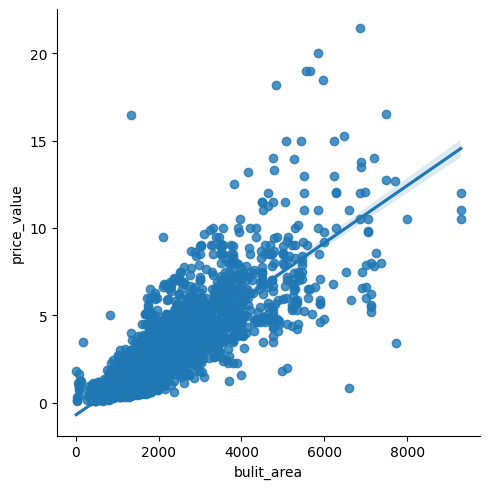

In [481]:
sns.lmplot(data=df, x="bulit_area", y="price_value")

In [504]:
from pathlib import Path
current = Path.cwd()
parent = current.parent
df.to_csv(parent/"data"/"interim_data.csv", index=False)